In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv('/content/drive/MyDrive/netflix_customer_churn.csv')

In [7]:
df

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,44f3ba44-b95d-4e50-a786-bac4d06f4a43,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama
4996,18779bcb-ba2b-41da-b751-e70b812061ec,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary
4997,3f32e8c5-615b-4a3b-a864-db2688f7834f,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action
4998,7b0ad82d-6571-430e-90f4-906259e0e89c,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi


In [8]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


**Dataset information**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

**Statistical summary**

In [10]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


**missing values**

In [11]:
df.isnull().sum()

,0
customer_id,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0


**duplicate rows**

In [12]:
df.duplicated().sum()

np.int64(0)

**EDA** Analyzing the Target Variable

churned
1    2515
0    2485
Name: count, dtype: int64
churned
1    50.3
0    49.7
Name: proportion, dtype: float64


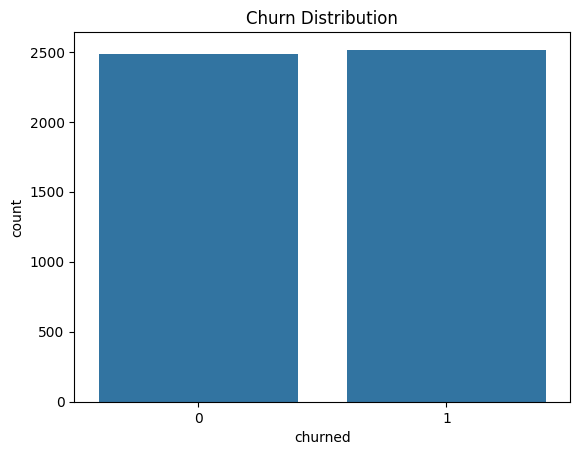

In [13]:
# Churn distribution
print(df['churned'].value_counts())

# Percentage distribution
print(df['churned'].value_counts(normalize=True) * 100)

# Visualize churn distribution
sns.countplot(x='churned', data=df)
plt.title("Churn Distribution")
plt.show()

**Numerical Feature Analysis**

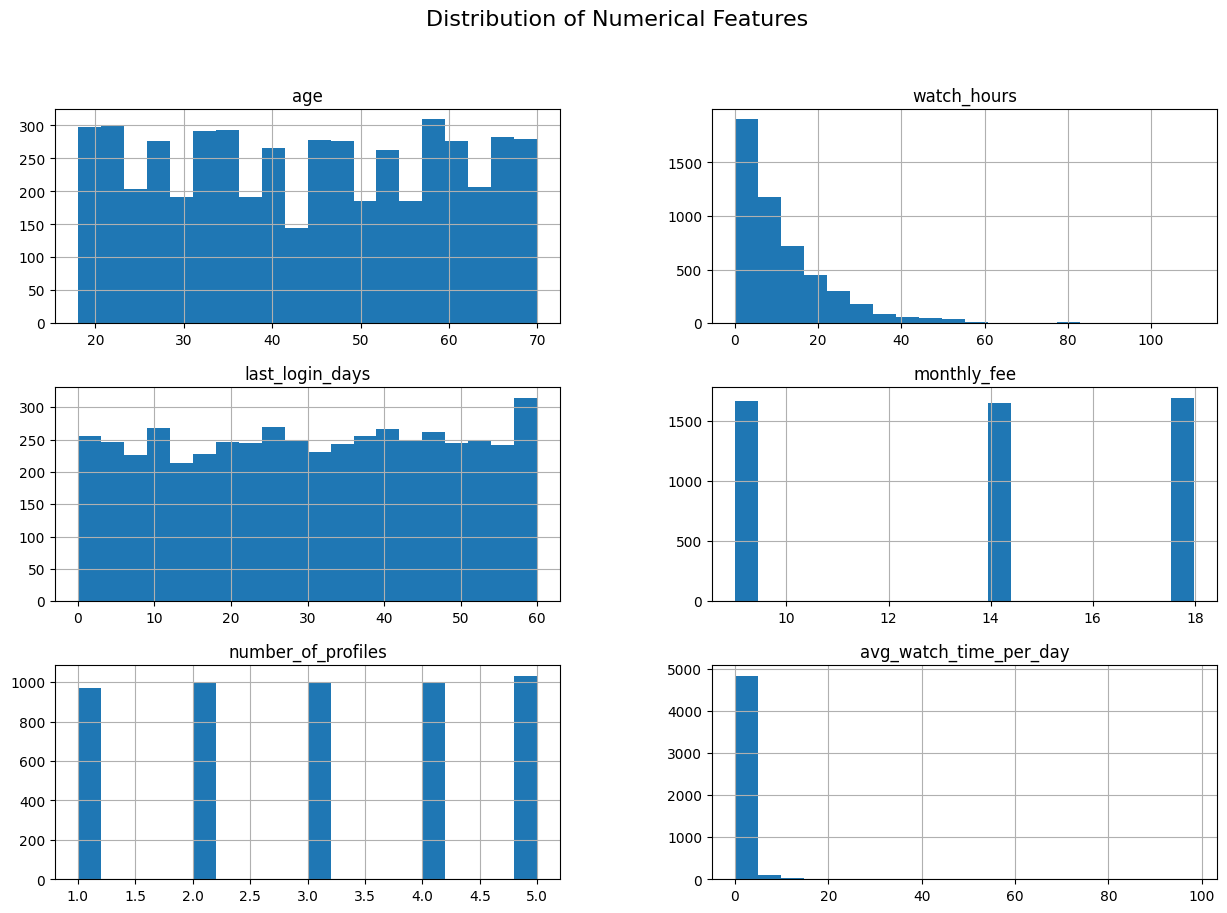

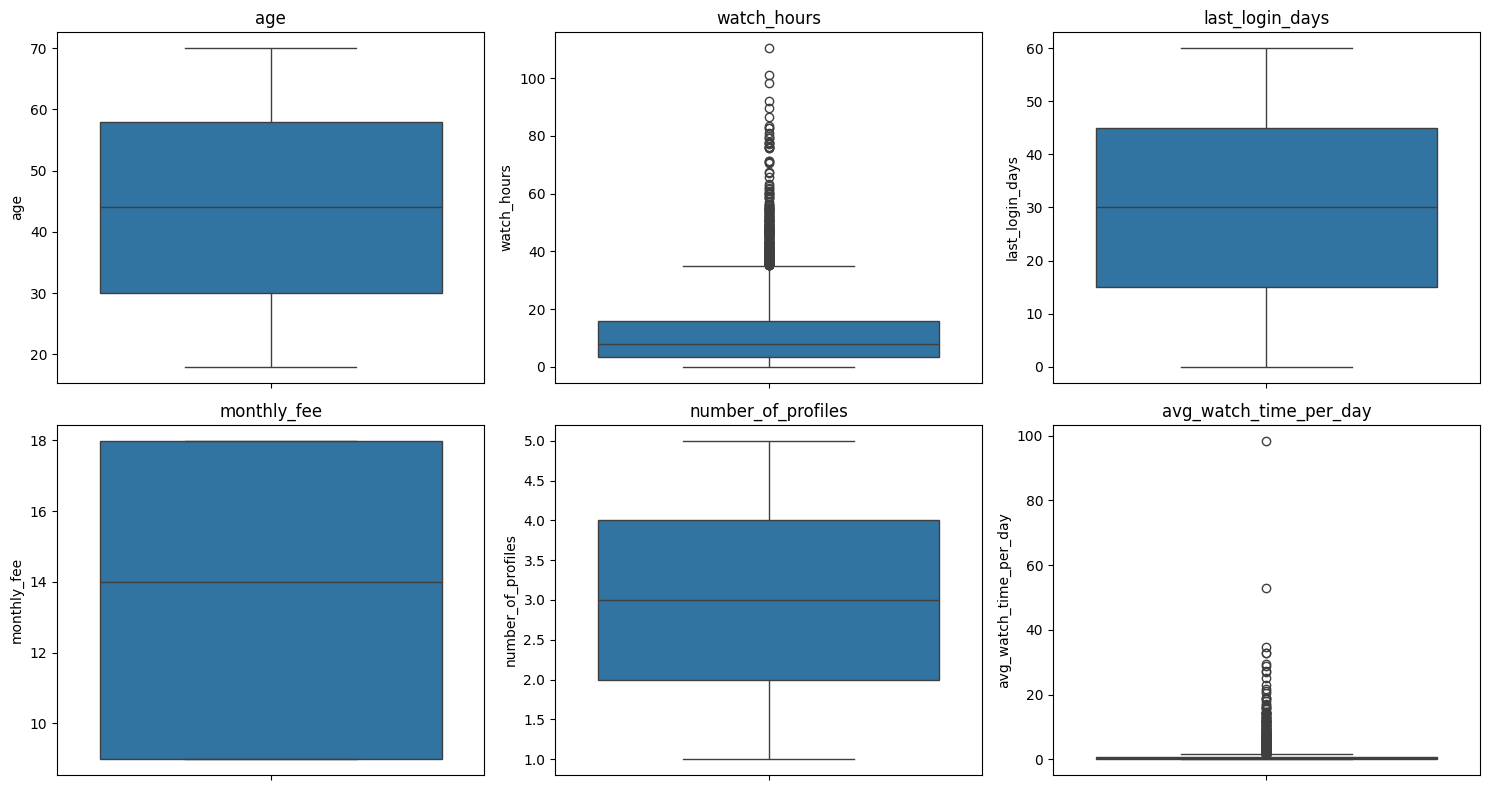

In [14]:
# Numerical columns
num_cols = ['age', 'watch_hours', 'last_login_days',
            'monthly_fee', 'number_of_profiles',
            'avg_watch_time_per_day']

# Histograms
df[num_cols].hist(figsize=(15, 10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# Boxplots for outlier detection
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Outlier Strategy**

In [15]:
# Function to cap outliers using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower_bound, upper_bound)

# Apply to skewed columns
cap_outliers(df, 'watch_hours')
cap_outliers(df, 'avg_watch_time_per_day')

# Verify the maximum values after capping
print("Max watch_hours:", df['watch_hours'].max())
print("Max avg_watch_time_per_day:", df['avg_watch_time_per_day'].max())

Max watch_hours: 35.06875
Max avg_watch_time_per_day: 1.635


which customer categories are most likely to churn.

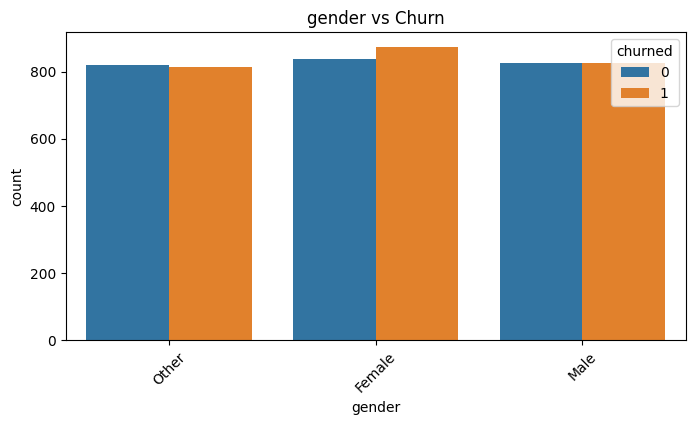

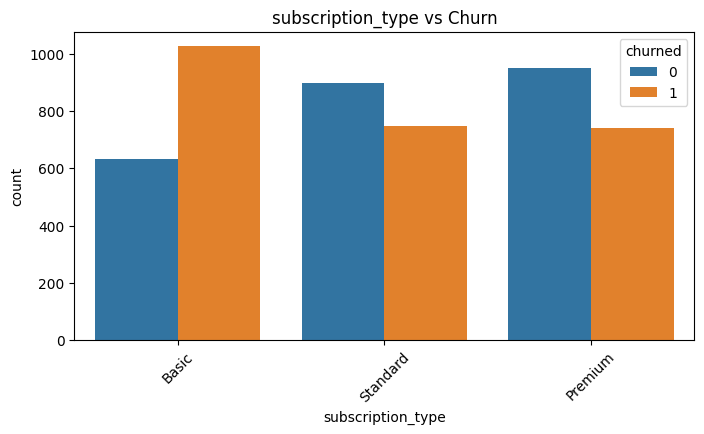

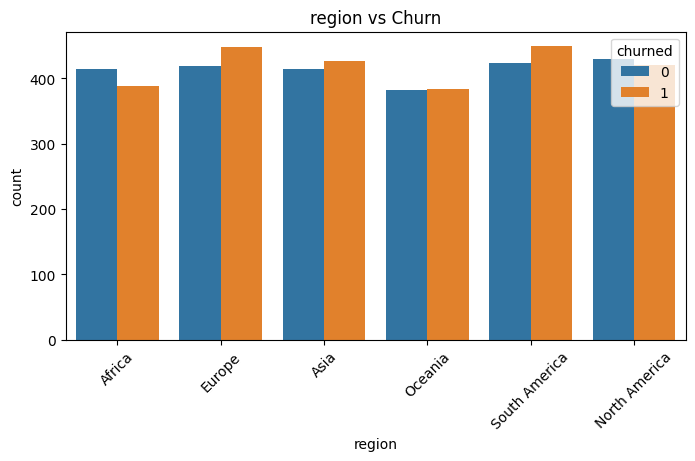

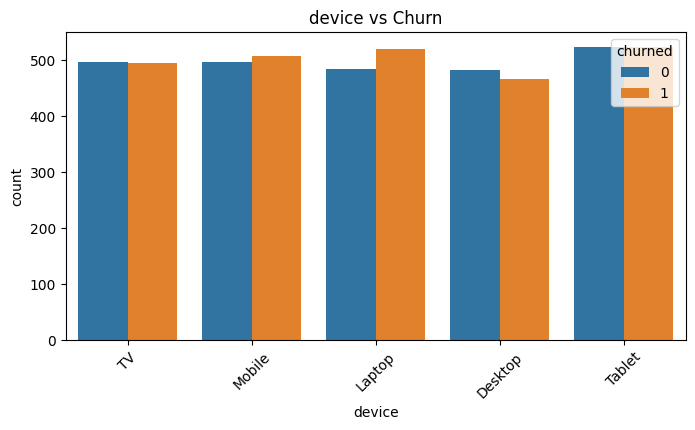

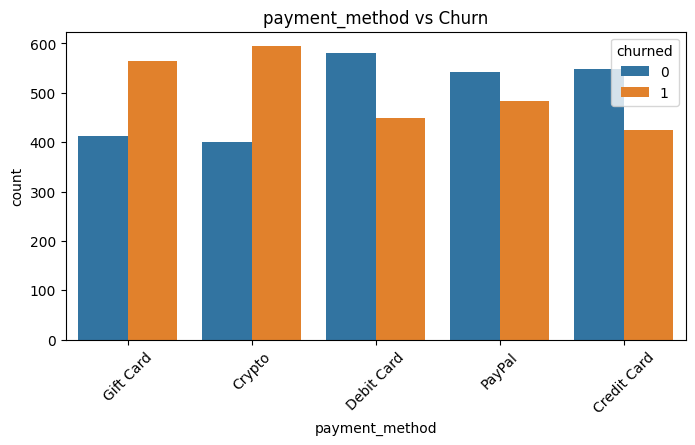

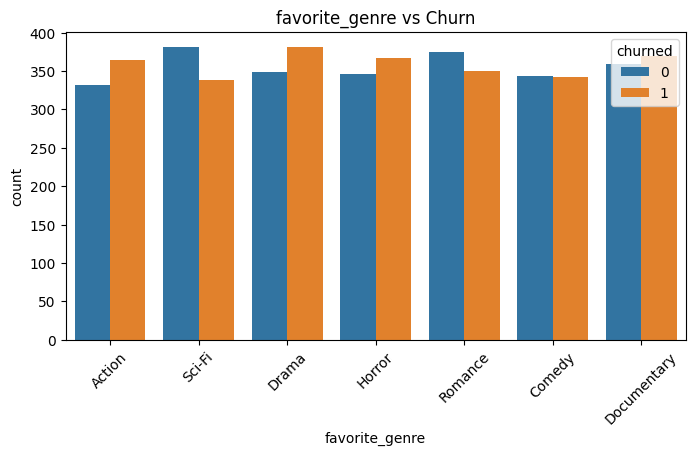

In [16]:
# Categorical columns
cat_cols = ['gender', 'subscription_type', 'region',
            'device', 'payment_method', 'favorite_genre']

# Plot churn rate by categorical features
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='churned', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

**Feature-Target Relationship Analysis** numerical features differ between churned and non-churned customers.

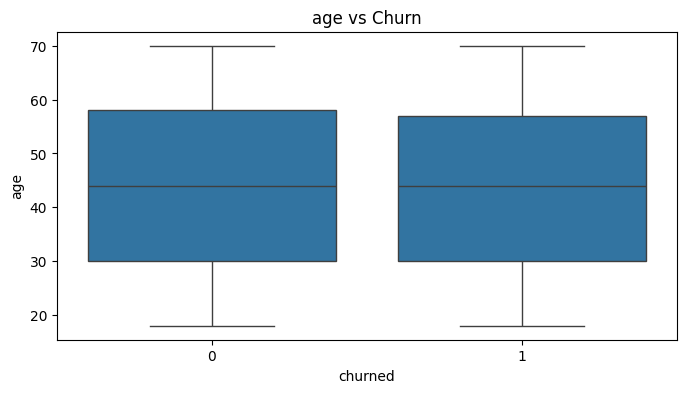

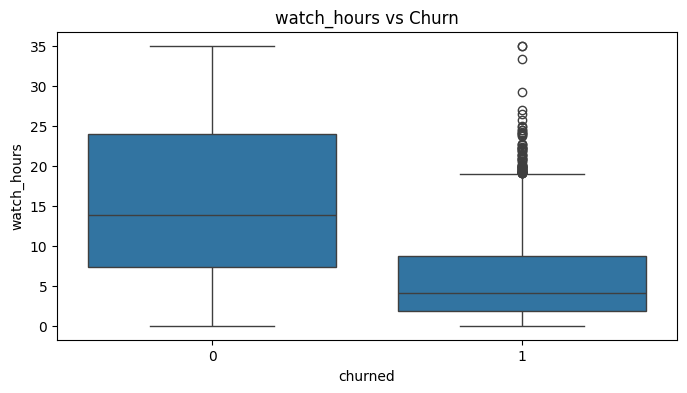

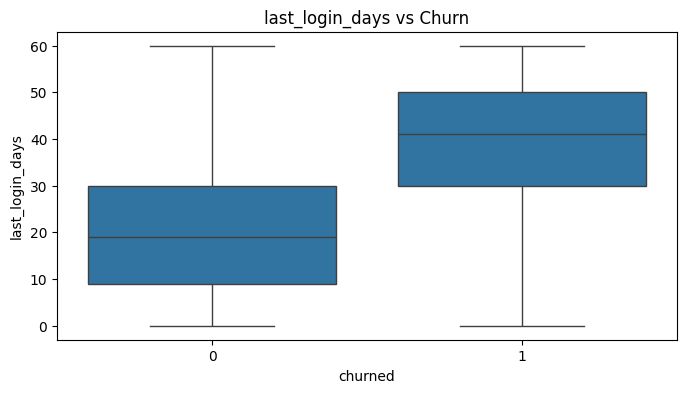

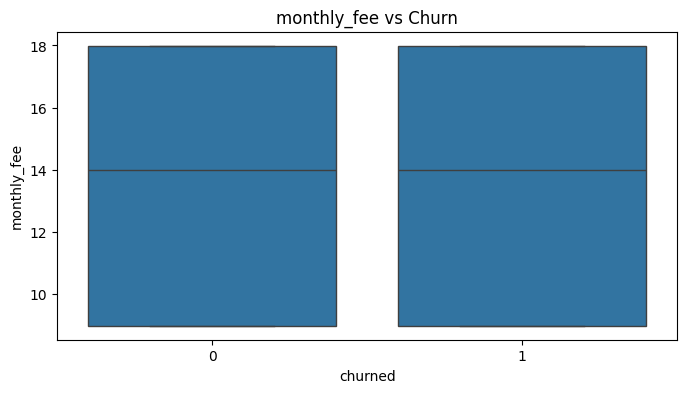

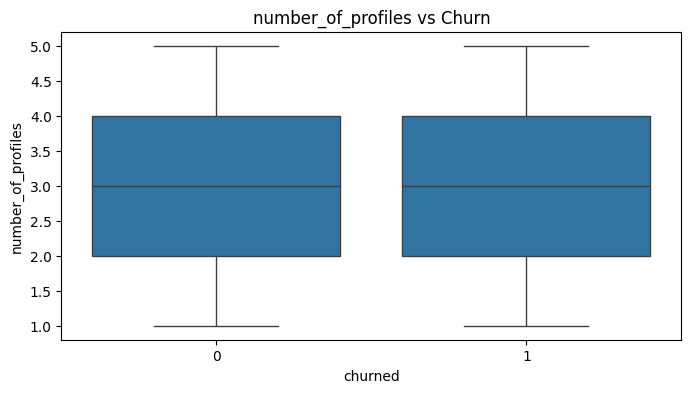

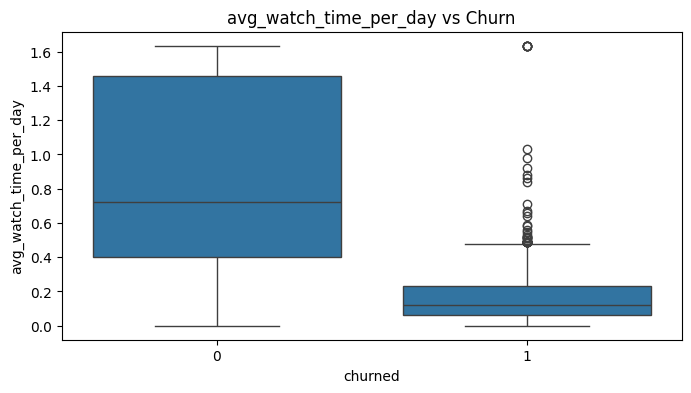

In [17]:

# Compare numerical features by churn status
num_cols = ['age', 'watch_hours', 'last_login_days',
            'monthly_fee', 'number_of_profiles',
            'avg_watch_time_per_day']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='churned', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

**Data Preprocessing**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop customer_id
df_model = df.drop('customer_id', axis=1)

# Separate features and target
X = df_model.drop('churned', axis=1)
y = df_model['churned']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:", list(categorical_cols))
print("Numerical Columns:", list(numerical_cols))

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Categorical Columns: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
Numerical Columns: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']
Training set shape: (4000, 12)
Testing set shape: (1000, 12)


Accuracy: 0.901

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       497
           1       0.88      0.92      0.90       503

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000


ROC-AUC Score: 0.9702789300414816


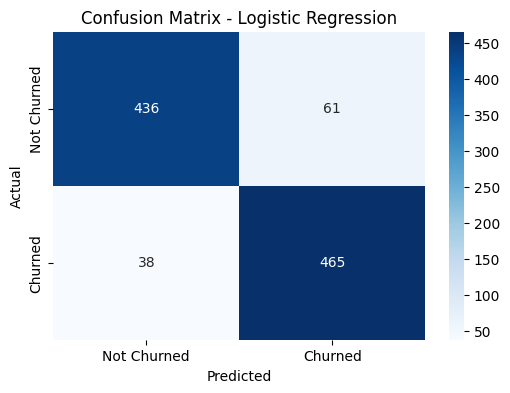

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Create the model pipeline
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt

**Create All Models**

In [21]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [22]:
print(X_train.dtypes)

age                         int64
gender                     object
subscription_type          object
watch_hours               float64
last_login_days             int64
region                     object
device                     object
monthly_fee               float64
payment_method             object
number_of_profiles          int64
avg_watch_time_per_day    float64
favorite_genre             object
dtype: object


In [23]:
import pandas as pd

# Encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

In [24]:
X_encoded.dtypes

,0
age,int64
watch_hours,float64
last_login_days,int64
monthly_fee,float64
number_of_profiles,int64
avg_watch_time_per_day,float64
gender_Male,bool
gender_Other,bool
subscription_type_Premium,bool
subscription_type_Standard,bool


Separate Features and Target

In [25]:
# Features
X = df.drop(columns=["customer_id", "churned"])

# Target
y = df["churned"]

One-Hot Encode Categorical Variables

In [26]:
import pandas as pd

# Convert categorical variables into numerical variables
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Shape after Encoding:", X_encoded.shape)
X_encoded.head()

Shape after Encoding: (5000, 29)


,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day,gender_Male,gender_Other,subscription_type_Premium,subscription_type_Standard,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
0,51,14.73,29,8.99,1,0.49,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,47,0.70,19,13.99,5,0.03,False,True,False,True,...,False,False,True,False,False,False,False,False,False,True
2,27,16.32,10,13.99,2,1.48,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
3,53,4.51,12,17.99,2,0.35,False,True,True,False,...,True,False,False,False,False,False,False,True,False,False
4,56,1.89,13,13.99,2,0.13,False,True,False,True,...,True,False,False,False,False,False,False,False,False,False


Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train_encoded, X_test_encoded, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train_encoded.shape)
print("Testing Shape  :", X_test_encoded.shape)

Training Shape : (4000, 29)
Testing Shape  : (1000, 29)


In [28]:
X_train_encoded
X_test_encoded

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day,gender_Male,gender_Other,subscription_type_Premium,subscription_type_Standard,...,payment_method_Crypto,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi
1911,67,26.05,21,13.99,4,1.18,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3551,67,2.34,54,17.99,4,0.04,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1241,69,6.06,30,8.99,4,0.20,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3182,31,9.44,46,8.99,2,0.20,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3678,59,0.10,20,17.99,1,0.00,False,False,True,False,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4324,26,2.87,50,13.99,3,0.06,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3511,30,10.47,50,13.99,4,0.21,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
395,42,7.27,7,8.99,2,0.91,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4240,18,7.70,33,8.99,2,0.23,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


Create Scaled Version

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

Now train the Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_encoded, y_train)

y_pred = dt.predict(X_test_encoded)
y_prob = dt.predict_proba(X_test_encoded)[:,1]

Evaluation

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.974
Precision: 0.9704142011834319
Recall   : 0.9781312127236581
F1 Score : 0.9742574257425742
ROC AUC  : 0.9739750631022718

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       497
           1       0.97      0.98      0.97       503

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



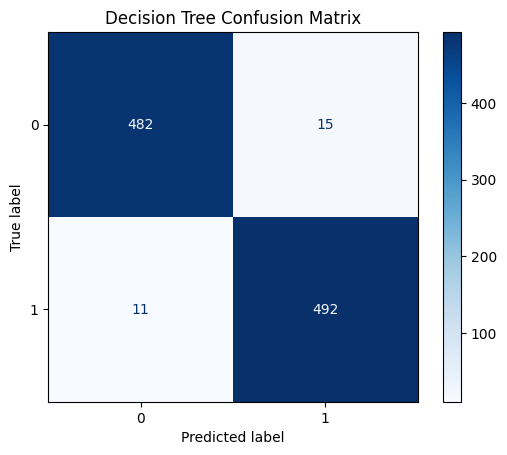

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test_encoded,
    y_test,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_encoded, y_train)

y_pred = rf.predict(X_test_encoded)
y_prob = rf.predict_proba(X_test_encoded)[:,1]

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Store results of all models
model_results = []

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

Random Forest
Accuracy : 0.9840
Precision: 0.9841
Recall   : 0.9841
F1 Score : 0.9841
ROC AUC  : 0.9977

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       497
           1       0.98      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



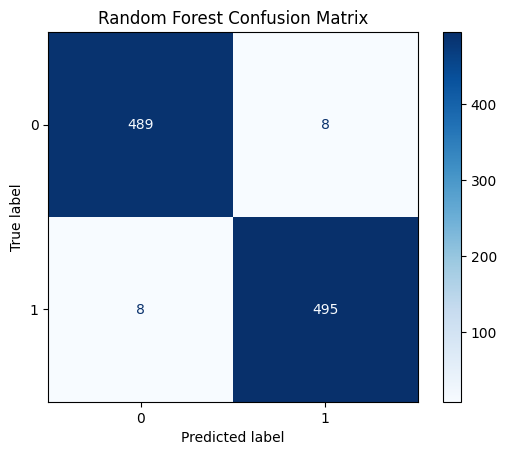

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_encoded, y_train)

evaluate_model(
    rf,
    X_test_encoded,
    y_test,
    "Random Forest"
)

Train KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

KNN
Accuracy : 0.8100
Precision: 0.7790
Recall   : 0.8688
F1 Score : 0.8214
ROC AUC  : 0.8763

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.75      0.80       497
           1       0.78      0.87      0.82       503

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



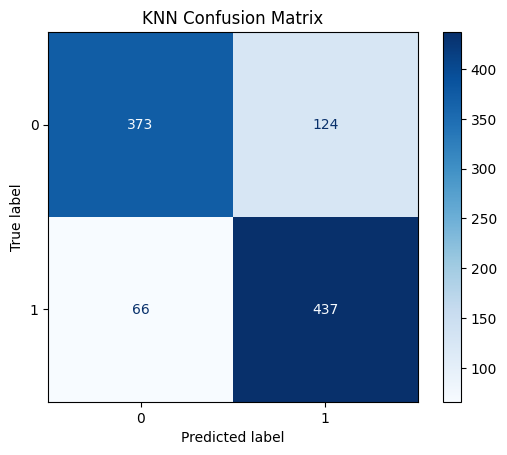

In [37]:
evaluate_model(
    knn,
    X_test_scaled,
    y_test,
    "KNN"
)

Support Vector Machine (SVM)

Support Vector Machine
Accuracy : 0.8930
Precision: 0.8736
Recall   : 0.9205
F1 Score : 0.8964
ROC AUC  : 0.9707

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       497
           1       0.87      0.92      0.90       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



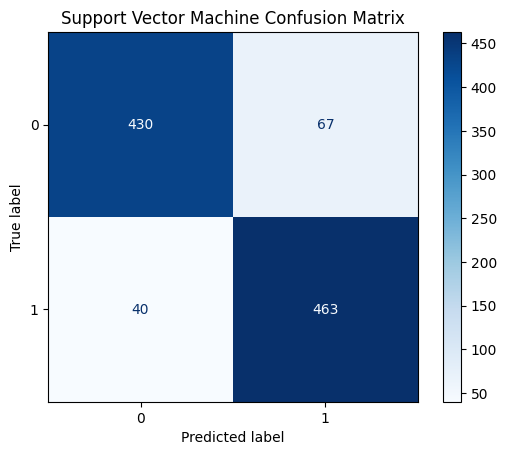

In [38]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    svm,
    X_test_scaled,
    y_test,
    "Support Vector Machine"
)

Naive Bayes

Naive Bayes
Accuracy : 0.8590
Precision: 0.8142
Recall   : 0.9324
F1 Score : 0.8693
ROC AUC  : 0.9501

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.78      0.85       497
           1       0.81      0.93      0.87       503

    accuracy                           0.86      1000
   macro avg       0.87      0.86      0.86      1000
weighted avg       0.87      0.86      0.86      1000



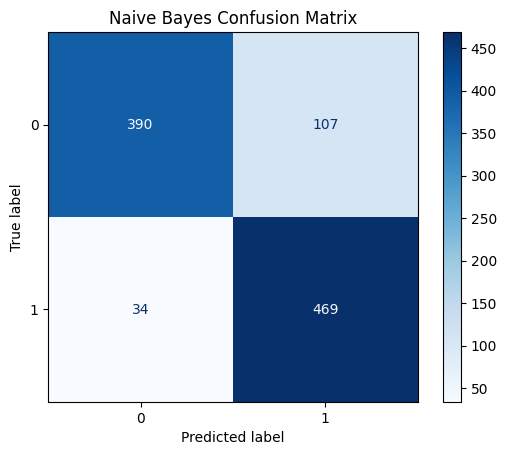

In [39]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(
    X_train_encoded,
    y_train
)

evaluate_model(
    nb,
    X_test_encoded,
    y_test,
    "Naive Bayes"
)

Gradient Boosting

Gradient Boosting
Accuracy : 0.9870
Precision: 0.9880
Recall   : 0.9861
F1 Score : 0.9871
ROC AUC  : 0.9978

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.99      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



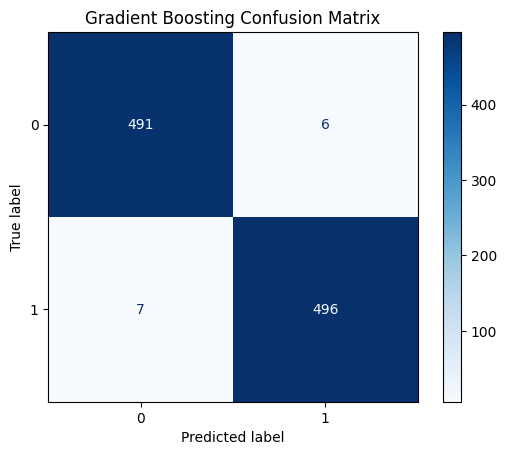

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train_encoded,
    y_train
)

evaluate_model(
    gb,
    X_test_encoded,
    y_test,
    "Gradient Boosting"
)

compare every model

In [41]:
import pandas as pd

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.987,0.988048,0.986083,0.987065,0.997844
1,Random Forest,0.984,0.984095,0.984095,0.984095,0.997666
2,Support Vector Machine,0.893,0.873585,0.920477,0.896418,0.970689
3,Naive Bayes,0.859,0.814236,0.932406,0.869323,0.950062
4,KNN,0.810,0.778966,0.868787,0.821429,0.876294


Top model performance is GB and RF, will perform Hyperparametr tunning in order to increase efficiency by adjusting the hyperparameter mannualy

**Tuning Random Forest**

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV Score:
0.9780000000000001


Evaluate Tuned Random Forest

Tuned Random Forest
Accuracy : 0.9810
Precision: 0.9840
Recall   : 0.9781
F1 Score : 0.9811
ROC AUC  : 0.9977

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       497
           1       0.98      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



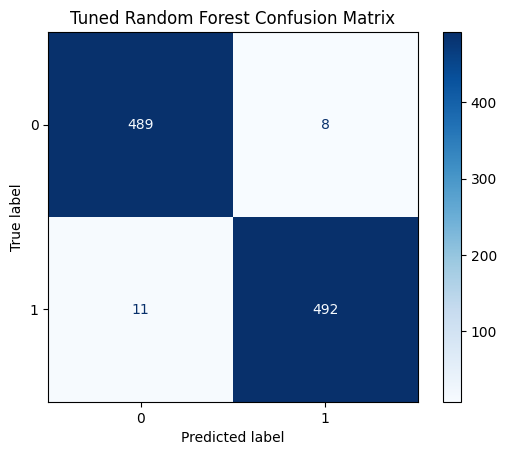

In [43]:
best_rf = grid_rf.best_estimator_

evaluate_model(
    best_rf,
    X_test_encoded,
    y_test,
    "Tuned Random Forest"
)

**Tuning Gradient Boosting**

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gb.fit(X_train_encoded, y_train)

print(grid_gb.best_params_)

{'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}


Evaluate Tuned Gradient Boosting

Tuned Gradient Boosting
Accuracy : 0.9940
Precision: 0.9980
Recall   : 0.9901
F1 Score : 0.9940
ROC AUC  : 0.9991

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       497
           1       1.00      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



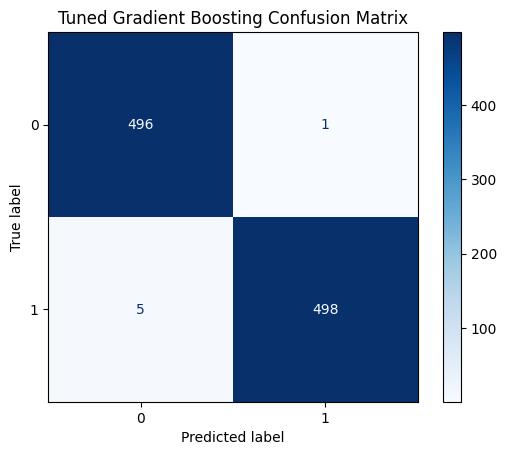

In [45]:
best_gb = grid_gb.best_estimator_

evaluate_model(
    best_gb,
    X_test_encoded,
    y_test,
    "Tuned Gradient Boosting"
)

**Feature Importance (Business Insight)** Why is the customer leaving?

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,avg_watch_time_per_day,6.516014e-01
1,watch_hours,9.055733e-02
4,number_of_profiles,8.979031e-02
2,last_login_days,8.194715e-02
3,monthly_fee,5.549968e-02
19,payment_method_Crypto,1.797615e-02
21,payment_method_Gift Card,1.136461e-02
20,payment_method_Debit Card,8.004164e-04
0,age,2.368631e-04
7,gender_Other,9.581466e-05


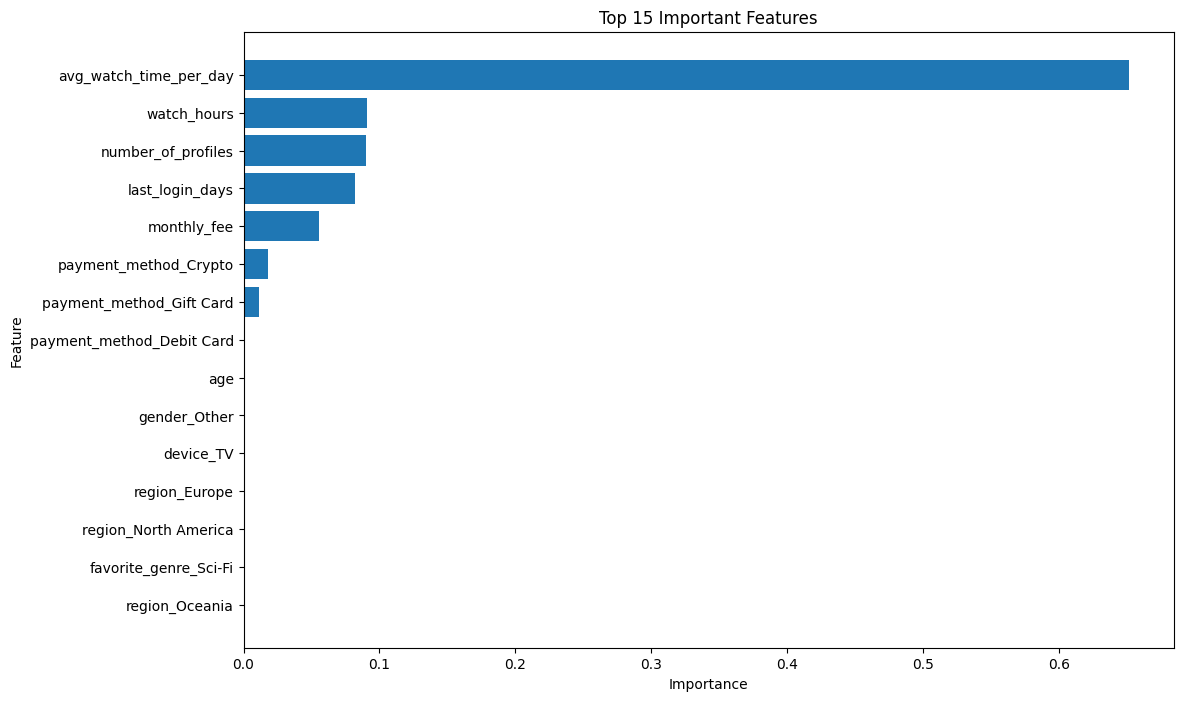

In [47]:
plt.figure(figsize=(12,8))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 15 Important Features")

plt.show()

In [48]:
feature_importance.to_csv(  #Save CSV
    "feature_importance.csv",
    index=False
)

In [49]:
import joblib #Save Model

joblib.dump(best_gb, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [50]:
joblib.dump( #Save Scaler
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [51]:
joblib.dump( #Save Feature Names
    X_train_encoded.columns.tolist(),
    "feature_names.pkl"
)

['feature_names.pkl']

In [52]:
loaded_model = joblib.load(
    "customer_churn_model.pkl"
)

prediction = loaded_model.predict(
    X_test_encoded.iloc[:5]
)

print(prediction)

[0 1 0 1 1]


sample customer prediction

In [53]:
sample_customer = X_test_encoded.iloc[[0]]

prediction = best_gb.predict(sample_customer)

probability = best_gb.predict_proba(sample_customer)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[1.00000000e+00 1.56732771e-10]]


Install SHAP

In [54]:
!pip install shap

In [55]:
import shap
import matplotlib.pyplot as plt

# Initialize JavaScript visualization (for notebooks)
shap.initjs()

In [56]:
explainer = shap.TreeExplainer(best_gb)

In [57]:
shap_values = explainer.shap_values(X_test_encoded)

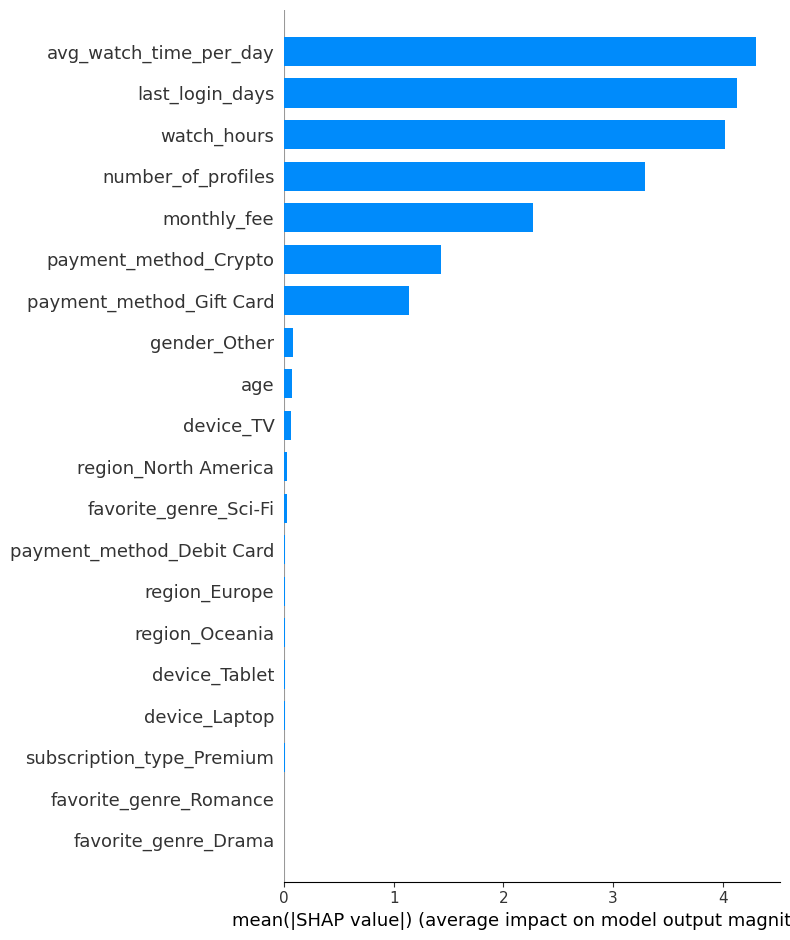

In [58]:
shap.summary_plot(
    shap_values,
    X_test_encoded,
    plot_type="bar"
)

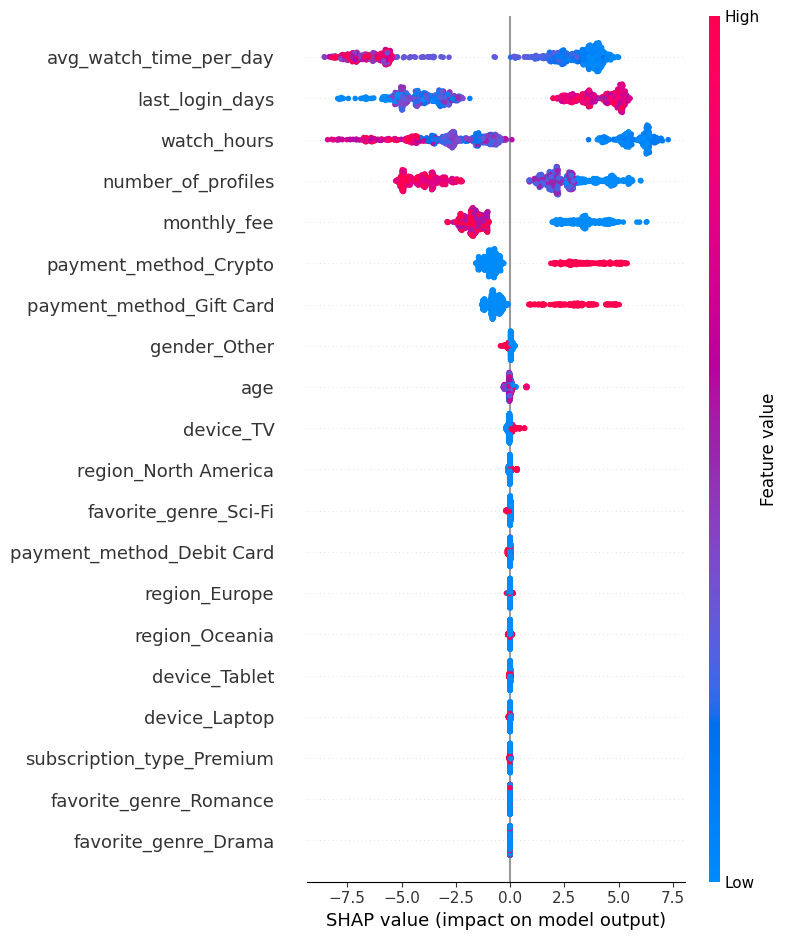

In [59]:
shap.summary_plot(
    shap_values,
    X_test_encoded
)

In [60]:
customer = X_test_encoded.iloc[[0]]

In [61]:
customer_shap = explainer.shap_values(customer)

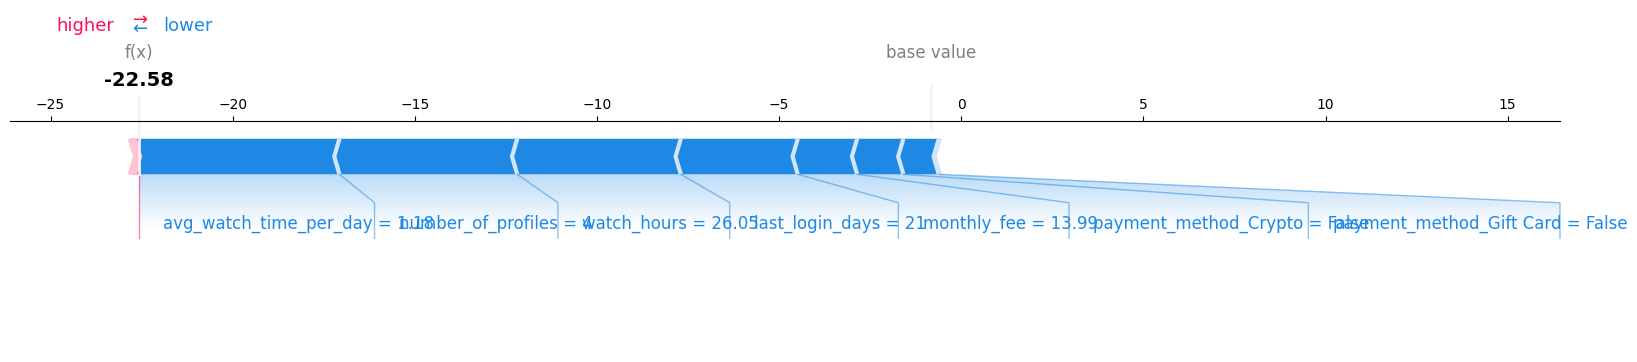

In [64]:
shap.force_plot(
    explainer.expected_value,
    customer_shap,
    customer,
    matplotlib=True
)

saving model into folder "models"

In [66]:
import os

# Create the folder if it doesn't exist
os.makedirs("models", exist_ok=True)

In [67]:
import joblib

joblib.dump(best_gb, "models/customer_churn_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(X_train_encoded.columns.tolist(), "models/feature_names.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [68]:
import os

os.listdir("models")

['feature_names.pkl', 'scaler.pkl', 'customer_churn_model.pkl']